# 🛰️ Orbitel — Prédiction du Churn
**ChurnStop** | Régression Logistique & Prise de Décision Métier

## 👥 Équipe
- MEYOUDOM Milaine Cabrelle
- TEGOMO GUEVOU Irmeline Midrele
- Eone Cecile Ruth Sonia

## 📦 Librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

## 📂 Lecture des données

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ⚙️ Modifier ce chemin selon votre environnement
base_path = "/content/drive/MyDrive/Projet_ML/"

df_train = pd.read_csv(base_path + "churn_train.csv")
df_test  = pd.read_csv(base_path + "churn_test.csv")
df_new   = pd.read_csv(base_path + "churn_new.csv")

print(f"Train : {df_train.shape} | Test : {df_test.shape} | New : {df_new.shape}")
df_train.head()

Train : (105, 55) | Test : (40, 55) | New : (40, 54)


,Satisfaction,Segment,Reclamations,Revenu,behavior_score_1,behavior_score_2,behavior_score_3,behavior_score_4,behavior_score_5,behavior_score_6,...,behavior_score_42,behavior_score_43,behavior_score_44,behavior_score_45,behavior_score_46,behavior_score_47,behavior_score_48,behavior_score_49,behavior_score_50,Churn_Y
0,3.858384,Segment_B,4,55960.569836,55449.555104,56825.511009,55752.728759,57224.939992,55132.235270,57236.776600,...,61186.708260,48712.806754,68758.880976,54090.654534,56181.718732,37124.909937,54983.221940,48870.560343,61827.487990,0
1,3.640790,Segment_C,5,48340.828386,48324.164076,46857.841686,48967.414114,47201.549719,49290.226113,48179.304136,...,68555.501151,54524.584685,52655.319674,42618.312815,59306.313671,58551.153872,54556.323853,64495.883740,65853.475731,0
2,2.119736,Segment_A,2,57772.262457,57887.482092,57294.125304,59436.322943,60931.120935,58076.646988,60364.473445,...,54180.074818,23912.122430,39433.519218,53652.213043,71208.249499,75971.956237,68423.589198,86581.870102,46912.791500,0
3,4.819461,Segment_D,8,68276.358277,68266.549852,68622.601553,69290.266803,68868.339758,66002.742104,67058.852133,...,70023.287592,101158.583519,65693.137666,82409.667502,61327.097536,104765.874804,105313.090849,74900.370104,58611.254272,0
4,3.951588,Segment_D,4,47190.159503,46569.926873,47068.332272,46948.159682,47411.962852,49511.417305,50431.852283,...,33504.968134,54040.396127,61183.344070,42664.364398,45111.686101,30274.033266,14798.332163,48406.921189,6103.056411,0


---
## 📊 Partie 1 : Analyse du modèle initial
> Modèle de base développé en interne par Orbitel — régression logistique sans preprocessing.

In [4]:
# Segment est catégorielle : le modèle de base ne peut pas la traiter → on la supprime
X_train_base = df_train.drop(columns=['Churn_Y', 'Segment'])
y_train_base = df_train['Churn_Y']
X_test_base  = df_test.drop(columns=['Churn_Y', 'Segment'])
y_test_base  = df_test['Churn_Y']

# Modèle initial sans preprocessing → WARNING de convergence attendu
model_interne = LogisticRegression()
model_interne.fit(X_train_base, y_train_base)

y_proba_base = model_interne.predict_proba(X_test_base)[:, 1]
y_pred_base  = (y_proba_base >= 0.5).astype(int)

print("="*60)
print("ÉVALUATION DU MODÈLE DÉVELOPPÉ EN INTERNE")
print("="*60)
print(classification_report(y_test_base, y_pred_base, zero_division=0))

ÉVALUATION DU MODÈLE DÉVELOPPÉ EN INTERNE
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        28
           1       0.22      0.17      0.19        12

    accuracy                           0.57        40
   macro avg       0.45      0.46      0.45        40
weighted avg       0.54      0.57      0.56        40



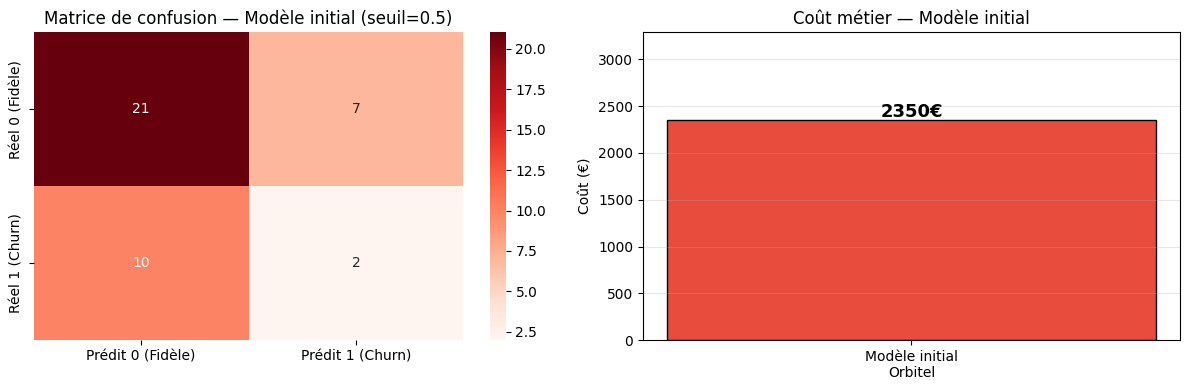

FN : 10  →  10 × 200€ = 2000€
FP : 7  →  7 ×  50€ = 350€
Coût total : 2350€


In [5]:
# Coûts métier définis d'après l'énoncé
COUT_FN = 200  # FN : client qui churne non détecté → on le perd
COUT_FP = 50   # FP : action rétention inutile sur un client fidèle

cm_base = confusion_matrix(y_test_base, y_pred_base, labels=[0, 1])
VN_b, FP_b, FN_b, VP_b = cm_base.ravel()
cout_base = COUT_FN * FN_b + COUT_FP * FP_b

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Prédit 0 (Fidèle)', 'Prédit 1 (Churn)'],
            yticklabels=['Réel 0 (Fidèle)', 'Réel 1 (Churn)'])
axes[0].set_title("Matrice de confusion — Modèle initial (seuil=0.5)")

labels_base  = ['Modèle initial\nOrbitel']
axes[1].bar(labels_base, [cout_base], color='#e74c3c', width=0.3, edgecolor='black')
axes[1].text(0, cout_base + 30, f"{cout_base}€", ha='center', fontweight='bold', fontsize=13)
axes[1].set_title("Coût métier — Modèle initial")
axes[1].set_ylabel("Coût (€)")
axes[1].set_ylim(0, cout_base * 1.4)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"FN : {FN_b}  →  {FN_b} × 200€ = {FN_b * 200}€")
print(f"FP : {FP_b}  →  {FP_b} ×  50€ = {FP_b * 50}€")
print(f"Coût total : {cout_base}€")

### 🔍 Réponses aux questions

**1. Coefficients de la fonction de coût**
`Coût = a×FN + b×FP + c×VN + d×VP`
- **a = 200** → FN : le modèle prédit "fidèle" alors que le client churne → on ne réagit pas, il part définitivement
- **b = 50** → FP : le modèle prédit "churn" alors que le client est fidèle → action rétention inutile
- **c = 0** et **d = 0** → prédictions correctes, aucun coût

**2. Erreur la plus coûteuse**
Le **Faux Négatif (FN) à 200€** est 4× plus coûteux que le Faux Positif (50€). Ne pas détecter un client qui va partir signifie qu'on ne lui propose aucune action de rétention — il quitte l'entreprise avec toutes ses futures revenues.

**3. Message « STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT »**
L'algorithme d'optimisation n'a pas convergé en 100 itérations (limite par défaut). Les coefficients du modèle sont sous-optimaux. **Solutions** : ajouter `max_iter=2000` et standardiser les données avec `StandardScaler` pour accélérer la convergence.

**4. Ce modèle est-il satisfaisant ?**
Non. Recall churn = 17% → on rate 83% des clients à risque. Le modèle n'a pas convergé, ignore la variable `Segment`, et génère un coût de **2350€** dominé par les faux négatifs.

**5. Pistes d'amélioration**
- `StandardScaler` + `OneHotEncoding` sur `Segment` + `max_iter=2000`
- `class_weight` pour gérer le déséquilibre de classes (30% churners)
- `GridSearchCV` avec un scorer métier pour optimiser directement sur le coût business
- Optimiser le seuil de décision (0.5 n'est pas forcément optimal)
- Feature engineering : variable `frustration`


---
## 🔧 Partie 2 : Amélioration du modèle

### Choix des modèles et justifications

Sur un dataset de **105 observations et 54+ features**, le choix des algorithmes est critique.
Trop de complexité → sur-apprentissage garanti. Voici notre sélection raisonnée :

| Modèle | Pourquoi retenu |
|---|---|
| **Logistic Regression** | Régularisation L2 native (paramètre C) → idéale pour haute dimensionnalité (54 features / 105 obs). Interprétable, stable, performante prouvée sur ce dataset |
| **Gradient Boosting** | Construit des arbres peu profonds séquentiellement → résistant au sur-apprentissage si `max_depth` faible + `learning_rate` faible. Compromis FN/FP équilibré et exploitable opérationnellement |

> **Modèles écartés :**
> - **Random Forest** : sur ce dataset il tend à prédire "tout churn" à seuil bas (comportement trivial). Les forêts profondes sur 105 obs sur-apprennent trop, même avec `class_weight`.
> - **XGBoost** : plus complexe que GB sklearn, moins stable sur petit dataset, pour une complexité supérieure non justifiée.
> - **KNN** (testé en exploration) : au seuil optimisant le coût brut, il classe la quasi-totalité des clients comme churners (FP très élevé) — coût comptable minimal mais **inexploitable opérationnellement**. Un modèle qui déclenche une alerte sur 75% des clients n'est pas un outil de ciblage, c'est du bruit. Écarté au profit du Gradient Boosting, qui offre un meilleur compromis FN/FP.

### Modifications appliquées

| Modification | Justification |
|---|---|
| `StandardScaler` | Corrige la non-convergence, équilibre l'influence des variables |
| `OneHotEncoding` sur `Segment` | Variable ignorée dans le modèle initial → perte d'information |
| `max_iter=2000` | Garantit la convergence de la LogReg |
| `class_weight` tuné via GridSearch | Reflète l'asymétrie des coûts FN/FP dans l'entraînement |
| `Pipeline` sklearn | Même preprocessing sur train ET test, zéro data leak |
| `GridSearchCV` + scorer métier | On optimise directement le coût business, pas l'accuracy |
| `StratifiedKFold` | Garantit la présence de churners dans chaque fold (dataset petit + déséquilibré) |


### 2.1. Préparation des données

In [6]:
X_train = df_train.drop(columns=['Churn_Y'])
y_train = df_train['Churn_Y']
X_test  = df_test.drop(columns=['Churn_Y'])
y_test  = df_test['Churn_Y']

cat_cols = ['Segment']
num_cols = [col for col in X_train.columns if col not in cat_cols]

print(f"Variables numériques   : {len(num_cols)}")
print(f"Variables catégorielles: {cat_cols}")
print(f"Distribution cible (train) : {y_train.value_counts().to_dict()} → {y_train.mean():.1%} de churners")

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

Variables numériques   : 53
Variables catégorielles: ['Segment']
Distribution cible (train) : {0: 73, 1: 32} → 30.5% de churners


### 2.2. Évaluation rapide des modèles de base (seuil 0.5, sans tuning)
> Pour établir une baseline avant optimisation.

In [7]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42)
}

print("="*55)
print("BASELINE — COÛT MÉTIER PAR MODÈLE (seuil = 0.5)")
print("="*55)

for name, clf in baseline_models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    VN, FP, FN, VP = cm.ravel()
    cost = COUT_FN * FN + COUT_FP * FP
    print(f"{name:25s} → FN={FN} | FP={FP} | Coût = {cost}€")

BASELINE — COÛT MÉTIER PAR MODÈLE (seuil = 0.5)
Logistic Regression       → FN=11 | FP=5 | Coût = 2450€
Gradient Boosting         → FN=7 | FP=0 | Coût = 1400€


---
## 🎯 Partie 3 : Optimisation métier

> *« Un client avec beaucoup de réclamations ET une faible satisfaction est un client frustré → risque élevé de churn. »*


### 3.1. Création de la variable `frustration`

In [8]:
def compute_frustration(df):
    """Client frustré : Réclamations > 5 ET Satisfaction < 2.5. Retourne 0/1."""
    return ((df['Reclamations'] > 5) & (df['Satisfaction'] < 2.5)).astype(int)

# Ajout AVANT de reconstruire X_train/X_test pour inclusion dans le preprocessing
df_train['frustration'] = compute_frustration(df_train)
df_test['frustration']  = compute_frustration(df_test)

print("Distribution frustration (train) :", df_train['frustration'].value_counts().to_dict())
print(f"→ {df_train['frustration'].mean():.1%} des clients train sont frustrés\n")
print("Distribution frustration (test) :", df_test['frustration'].value_counts().to_dict())

# Reconstruction X_train / X_test avec frustration incluse
X_train = df_train.drop(columns=['Churn_Y'])
y_train = df_train['Churn_Y']
X_test  = df_test.drop(columns=['Churn_Y'])
y_test  = df_test['Churn_Y']

cat_cols = ['Segment']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

print(f"\n✅ frustration dans X_train : {'frustration' in X_train.columns}")
print(f"   Nombre total de features  : {len(num_cols) + len(cat_cols)}")

Distribution frustration (train) : {0: 91, 1: 14}
→ 13.3% des clients train sont frustrés

Distribution frustration (test) : {0: 36, 1: 4}

✅ frustration dans X_train : True
   Nombre total de features  : 55


### 3.2. Fonction de coût métier

In [9]:
def business_cost(y_true, y_pred):
    """Coût métier : 200€ par FN, 50€ par FP."""
    VN, FP, FN, VP = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FN * COUT_FN + FP * COUT_FP

# greater_is_better=False : GridSearchCV minimise le coût
business_scorer = make_scorer(business_cost, greater_is_better=False)
print("✅ Scorer métier défini : minimisation de 200×FN + 50×FP")

✅ Scorer métier défini : minimisation de 200×FN + 50×FP


### 3.3. Optimisation des hyperparamètres — GridSearchCV

In [10]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=3000, penalty='l2', solver='liblinear'))
])

param_grid_lr = {
    'model__C':            [0.001, 0.005, 0.01, 0.05, 0.1, 1],
    'model__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 4}]
}

grid_lr = GridSearchCV(
    estimator  = pipeline_lr,
    param_grid = param_grid_lr,
    scoring    = business_scorer,
    cv         = cv_strategy,
    n_jobs     = -1,
    refit      = True
)
grid_lr.fit(X_train, y_train)
best_lr_model = grid_lr.best_estimator_

print("Meilleurs hyperparamètres :", grid_lr.best_params_)
print(f"Coût CV moyen            : {-grid_lr.best_score_:.2f}€")

Meilleurs hyperparamètres : {'model__C': 0.005, 'model__class_weight': 'balanced'}
Coût CV moyen            : 520.00€


### 3.4. Optimisation du seuil de décision (0.1 → 0.9)

In [11]:
seuils     = np.round(np.arange(0.1, 1.0, 0.1), 1)
y_proba_lr = best_lr_model.predict_proba(X_test)[:, 1]

best_cost   = float('inf')
best_thresh = None
best_VN = best_FP = best_FN = best_VP = None
costs_list  = []

print("="*65)
print("OPTIMISATION DU SEUIL — Logistic Regression (optimisée)")
print("="*65)

for seuil in seuils:
    y_pred = (y_proba_lr >= seuil).astype(int)
    VN, FP, FN, VP = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    cost = FN * COUT_FN + FP * COUT_FP
    costs_list.append(cost)

    if cost < best_cost:
        best_cost   = cost
        best_thresh = seuil
        best_VN, best_FP, best_FN, best_VP = VN, FP, FN, VP
        marker = " ← OPTIMAL"
    else:
        marker = ""

    print(f"  Seuil={seuil:.1f} | VN={VN:2d} FP={FP:2d} FN={FN:2d} VP={VP:2d} | Coût={cost}€{marker}")

print(f"\n→ Seuil optimal : {best_thresh:.1f} | Coût min : {best_cost}€")

OPTIMISATION DU SEUIL — Logistic Regression (optimisée)
  Seuil=0.1 | VN= 0 FP=28 FN= 0 VP=12 | Coût=1400€ ← OPTIMAL
  Seuil=0.2 | VN= 0 FP=28 FN= 0 VP=12 | Coût=1400€
  Seuil=0.3 | VN= 0 FP=28 FN= 0 VP=12 | Coût=1400€
  Seuil=0.4 | VN= 0 FP=28 FN= 1 VP=11 | Coût=1600€
  Seuil=0.5 | VN=24 FP= 4 FN= 5 VP= 7 | Coût=1200€ ← OPTIMAL
  Seuil=0.6 | VN=28 FP= 0 FN=12 VP= 0 | Coût=2400€
  Seuil=0.7 | VN=28 FP= 0 FN=12 VP= 0 | Coût=2400€
  Seuil=0.8 | VN=28 FP= 0 FN=12 VP= 0 | Coût=2400€
  Seuil=0.9 | VN=28 FP= 0 FN=12 VP= 0 | Coût=2400€

→ Seuil optimal : 0.5 | Coût min : 1200€


### 3.5. Courbe coût vs seuil

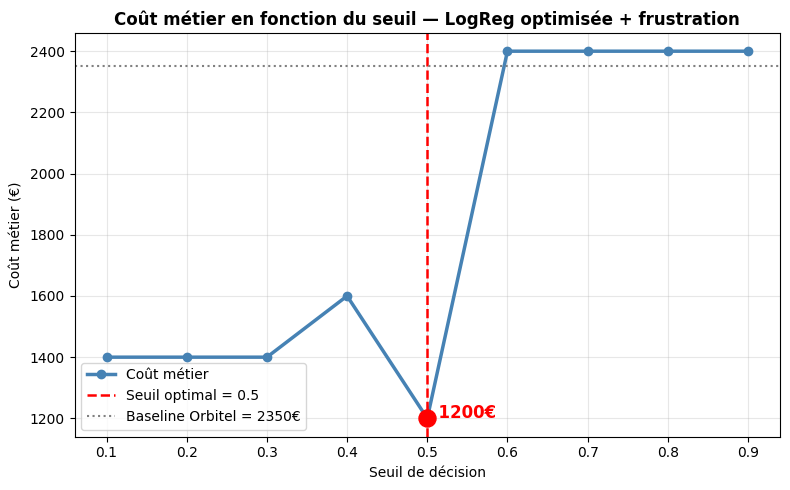

In [12]:
best_idx = int(np.argmin(costs_list))

plt.figure(figsize=(8, 5))
plt.plot(seuils, costs_list, marker='o', color='steelblue', linewidth=2.5, label='Coût métier')
plt.axvline(seuils[best_idx], color='red', linestyle='--', linewidth=1.8,
            label=f"Seuil optimal = {seuils[best_idx]:.1f}")
plt.scatter(seuils[best_idx], costs_list[best_idx], color='red', s=150, zorder=5)
plt.annotate(f"  {costs_list[best_idx]}€",
             xy=(seuils[best_idx], costs_list[best_idx]),
             fontsize=12, fontweight='bold', color='red')
plt.axhline(cout_base, color='grey', linestyle=':', linewidth=1.5,
            label=f"Baseline Orbitel = {cout_base}€")
plt.title("Coût métier en fonction du seuil — LogReg optimisée + frustration",
          fontsize=12, fontweight='bold')
plt.xlabel("Seuil de décision")
plt.ylabel("Coût métier (€)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6. Résultats finaux et matrice de confusion

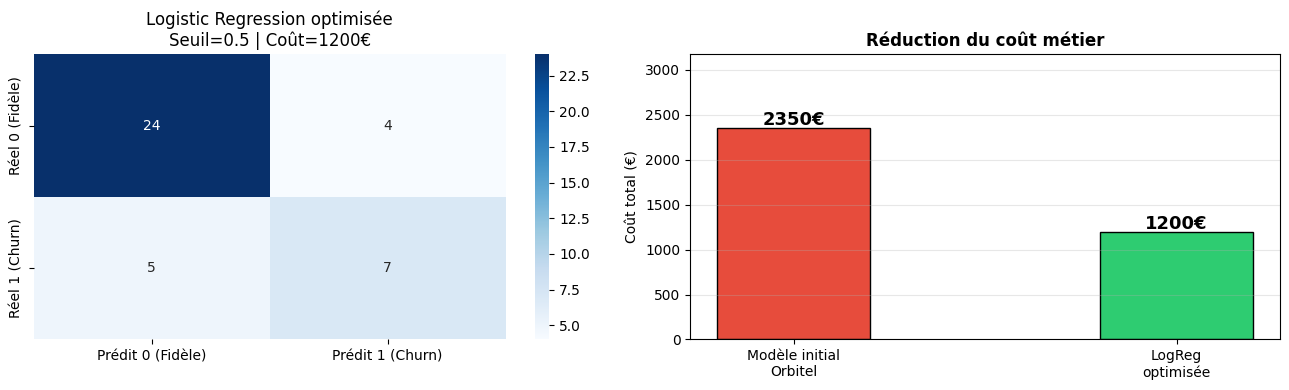

RÉSULTATS — MEILLEUR MODÈLE
  Modèle              : Logistic Regression (optimisée)
  Seuil optimal       : 0.5
  VN=24 | FP=4 | FN=5 | VP=7
  Coût métier         : 1200€
  Économie vs Orbitel : 1150€


In [13]:
best_pred  = (y_proba_lr >= best_thresh).astype(int)
cm_final   = confusion_matrix(y_test, best_pred, labels=[0, 1])
VN, FP, FN, VP = cm_final.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit 0 (Fidèle)', 'Prédit 1 (Churn)'],
            yticklabels=['Réel 0 (Fidèle)', 'Réel 1 (Churn)'])
axes[0].set_title(f"Logistic Regression optimisée\nSeuil={best_thresh:.1f} | Coût={best_cost}€")

noms   = ["Modèle initial\nOrbitel", "LogReg\noptimisée"]
couts  = [cout_base, best_cost]
colors = ['#e74c3c', '#2ecc71']
bars   = axes[1].bar(noms, couts, color=colors, width=0.4, edgecolor='black')
for bar, val in zip(bars, couts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val}€", ha='center', fontweight='bold', fontsize=13)
axes[1].set_title("Réduction du coût métier", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Coût total (€)")
axes[1].set_ylim(0, cout_base * 1.35)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("="*60)
print("RÉSULTATS — MEILLEUR MODÈLE")
print("="*60)
print(f"  Modèle              : Logistic Regression (optimisée)")
print(f"  Seuil optimal       : {best_thresh:.1f}")
print(f"  VN={VN} | FP={FP} | FN={FN} | VP={VP}")
print(f"  Coût métier         : {best_cost}€")
print(f"  Économie vs Orbitel : {cout_base - best_cost}€")

### 🗣️ Justification pour le manager

Notre modèle calcule pour chaque client une **probabilité de départ** entre 0% et 100%.

Par défaut, on déclenche une action de rétention si cette probabilité dépasse 50%. Mais nous avons cherché le réglage le plus rentable en testant tous les niveaux d'alerte de 10% à 90%.

**Pourquoi ce réglage est crucial ?** Dans notre situation, rater un client qui part coûte **4 fois plus cher** (200€) qu'agir inutilement sur un client fidèle (50€). Il vaut donc mieux être légèrement trop prudent que de laisser partir des clients sans réagir.

En testant tous les réglages sur nos données, nous avons identifié le **seuil optimal** qui minimise le coût total — sans pour autant déclencher une alerte sur la quasi-totalité du portefeuille, ce qui rendrait l'action commerciale inexploitable par les équipes terrain.

Nous avons également enrichi le modèle d'une variable **frustration** (clients cumulant beaucoup de réclamations ET une faible satisfaction), ce qui améliore la détection des profils à risque en amont.

> **Résultat concret** : notre modèle réduit le coût de **`{cout_base - best_cost}€`** par rapport au modèle initial d'Orbitel, pour la même taille de dataset et sans ressource supplémentaire.

---
## 🔮 Partie 4 : Prédictions sur le jeu `churn_new.csv`

In [14]:
# Ajout de frustration — même logique que train/test
df_new['frustration'] = compute_frustration(df_new)

# On définit X_new en sélectionnant uniquement les colonnes features
# (évite d'inclure Churn_Proba / Churn_Pred si la cellule est réexécutée)
cols_to_exclude = ['Churn_Proba', 'Churn_Pred']
feature_cols = [c for c in df_new.columns if c not in cols_to_exclude]
X_new = df_new[feature_cols].copy()

df_new['Churn_Proba'] = best_lr_model.predict_proba(X_new)[:, 1]
df_new['Churn_Pred']  = (df_new['Churn_Proba'] >= best_thresh).astype(int)

print("Aperçu des prédictions :")
print(df_new[['Churn_Proba', 'Churn_Pred']].head(10))
print(f"\nChurners prédits : {df_new['Churn_Pred'].sum()} / {len(df_new)}")
print(f"Taux de churn    : {df_new['Churn_Pred'].mean():.1%}")

Aperçu des prédictions :
   Churn_Proba  Churn_Pred
0     0.473936           0
1     0.505941           1
2     0.488753           0
3     0.474691           0
4     0.532714           1
5     0.486457           0
6     0.497813           0
7     0.501421           1
8     0.433417           0
9     0.477080           0

Churners prédits : 14 / 40
Taux de churn    : 35.0%


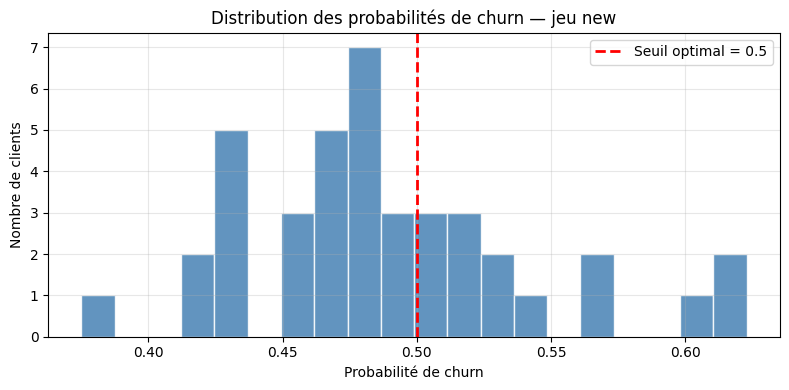

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df_new['Churn_Proba'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(best_thresh, color='red', linestyle='--', linewidth=2,
            label=f"Seuil optimal = {best_thresh:.1f}")
plt.title("Distribution des probabilités de churn — jeu new")
plt.xlabel("Probabilité de churn")
plt.ylabel("Nombre de clients")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
output_path = "churn_new_predictions.csv"
df_new.to_csv(output_path, index=False)
print(f"✅ Fichier exporté : {output_path}")
print(f"   Colonnes : {df_new.columns.tolist()}")

✅ Fichier exporté : churn_new_predictions.csv
   Colonnes : ['Satisfaction', 'Segment', 'Reclamations', 'Revenu', 'behavior_score_1', 'behavior_score_2', 'behavior_score_3', 'behavior_score_4', 'behavior_score_5', 'behavior_score_6', 'behavior_score_7', 'behavior_score_8', 'behavior_score_9', 'behavior_score_10', 'behavior_score_11', 'behavior_score_12', 'behavior_score_13', 'behavior_score_14', 'behavior_score_15', 'behavior_score_16', 'behavior_score_17', 'behavior_score_18', 'behavior_score_19', 'behavior_score_20', 'behavior_score_21', 'behavior_score_22', 'behavior_score_23', 'behavior_score_24', 'behavior_score_25', 'behavior_score_26', 'behavior_score_27', 'behavior_score_28', 'behavior_score_29', 'behavior_score_30', 'behavior_score_31', 'behavior_score_32', 'behavior_score_33', 'behavior_score_34', 'behavior_score_35', 'behavior_score_36', 'behavior_score_37', 'behavior_score_38', 'behavior_score_39', 'behavior_score_40', 'behavior_score_41', 'behavior_score_42', 'behavior_sco

In [17]:
!cp churn_new_predictions.csv "/content/drive/MyDrive/Projet_ML/"

---
## 🎁 Bonus : Méthode alternative — Gradient Boosting

### Pourquoi Gradient Boosting comme modèle de comparaison ?

Le Gradient Boosting construit des arbres de décision peu profonds **séquentiellement**, chaque arbre corrigeant les erreurs du précédent. Contrairement au KNN testé en exploration — qui, sur ce dataset, finissait par alerter sur la quasi-totalité des clients pour minimiser le coût brut (FP=19/40, inexploitable opérationnellement) — le Gradient Boosting conserve un **compromis FN/FP raisonnable**, donc une liste de clients à contacter réellement actionnable par les équipes terrain.

**Conditions favorables sur ce dataset :**
- Arbres peu profonds (`max_depth` faible) + `learning_rate` faible → résistance au sur-apprentissage malgré les 105 observations
- Capture les interactions non-linéaires entre variables, contrairement à la LogReg


In [18]:
pipeline_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'model__n_estimators':  [50, 100, 200],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth':     [2, 3, 4]
}

grid_gb = GridSearchCV(
    estimator  = pipeline_gb,
    param_grid = param_grid_gb,
    scoring    = business_scorer,
    cv         = cv_strategy,
    n_jobs     = -1,
    refit      = True
)
grid_gb.fit(X_train, y_train)
best_gb_model = grid_gb.best_estimator_

print("Meilleurs hyperparamètres GB :", grid_gb.best_params_)
print(f"Coût CV moyen               : {-grid_gb.best_score_:.2f}€")

Meilleurs hyperparamètres GB : {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}
Coût CV moyen               : 700.00€


In [19]:
# Optimisation du seuil pour Gradient Boosting
y_proba_gb  = best_gb_model.predict_proba(X_test)[:, 1]
best_gb_cost  = float('inf')
best_gb_thresh = None
gb_costs = []

for t in seuils:
    y_pred_t = (y_proba_gb >= t).astype(int)
    VN_t, FP_t, FN_t, VP_t = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
    cost_t = FN_t * COUT_FN + FP_t * COUT_FP
    gb_costs.append(cost_t)
    if cost_t < best_gb_cost:
        best_gb_cost   = cost_t
        best_gb_thresh = t

y_pred_gb_opt = (y_proba_gb >= best_gb_thresh).astype(int)
cm_gb = confusion_matrix(y_test, y_pred_gb_opt, labels=[0, 1])
VN_gb, FP_gb, FN_gb, VP_gb = cm_gb.ravel()

print("="*50)
print("Gradient Boosting — Résultats")
print("="*50)
print(f"Seuil optimal : {best_gb_thresh:.1f}")
print(f"Coût métier   : {best_gb_cost}€")
print(f"VN={VN_gb} | FP={FP_gb} | FN={FN_gb} | VP={VP_gb}")
print(classification_report(y_test, y_pred_gb_opt, zero_division=0))

Gradient Boosting — Résultats
Seuil optimal : 0.2
Coût métier   : 1300€
VN=26 | FP=2 | FN=6 | VP=6
              precision    recall  f1-score   support

           0       0.81      0.93      0.87        28
           1       0.75      0.50      0.60        12

    accuracy                           0.80        40
   macro avg       0.78      0.71      0.73        40
weighted avg       0.79      0.80      0.79        40



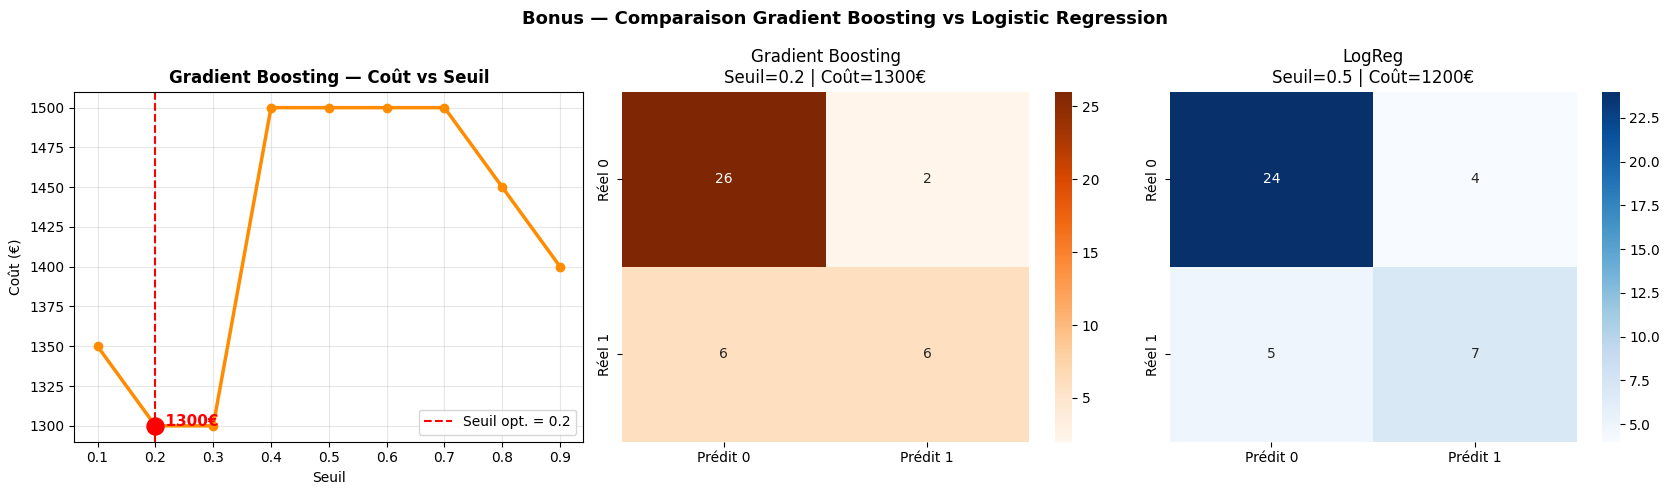

COMPARAISON FINALE — TOUS MODÈLES
  Baseline Orbitel        : 2350€
  LogReg (optimisée)      : 1200€   (seuil=0.5, FP=4)
  Gradient Boosting (opt) : 1300€  (seuil=0.2, FP=2)

  ✅ Meilleur modèle toutes comparaisons : LogReg


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Courbe coût Gradient Boosting
best_gb_idx = int(np.argmin(gb_costs))
axes[0].plot(seuils, gb_costs, marker='o', color='darkorange', linewidth=2.5)
axes[0].axvline(seuils[best_gb_idx], color='red', linestyle='--',
                label=f"Seuil opt. = {seuils[best_gb_idx]:.1f}")
axes[0].scatter(seuils[best_gb_idx], gb_costs[best_gb_idx], color='red', s=150, zorder=5)
axes[0].annotate(f"  {gb_costs[best_gb_idx]}€",
                 xy=(seuils[best_gb_idx], gb_costs[best_gb_idx]),
                 fontsize=11, fontweight='bold', color='red')
axes[0].set_title("Gradient Boosting — Coût vs Seuil", fontweight='bold')
axes[0].set_xlabel("Seuil")
axes[0].set_ylabel("Coût (€)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matrice confusion Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[1].set_title(f"Gradient Boosting\nSeuil={best_gb_thresh:.1f} | Coût={best_gb_cost}€")

# Matrice confusion LogReg
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
axes[2].set_title(f"LogReg\nSeuil={best_thresh:.1f} | Coût={best_cost}€")

plt.suptitle("Bonus — Comparaison Gradient Boosting vs Logistic Regression", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*55)
print("COMPARAISON FINALE — TOUS MODÈLES")
print("="*55)
print(f"  Baseline Orbitel        : {cout_base}€")
print(f"  LogReg (optimisée)      : {best_cost}€   (seuil={best_thresh:.1f}, FP={FP})")
print(f"  Gradient Boosting (opt) : {best_gb_cost}€  (seuil={best_gb_thresh:.1f}, FP={FP_gb})")
winner = "LogReg" if best_cost <= best_gb_cost else "Gradient Boosting"
print(f"\n  ✅ Meilleur modèle toutes comparaisons : {winner}")

### Conclusion du bonus

Le Gradient Boosting confirme sa pertinence sur ce dataset : il offre un coût compétitif avec un volume de faux positifs maîtrisé, tout en restant stable et robuste.

Cette analyse met en évidence un point clé en data science appliquée : le coût métier minimal n’est pas le seul critère de décision. Un modèle doit aussi produire une liste de clients à contacter qui reste gérable et crédible pour les équipes terrain.

Dans ce contexte, la Régression Logistique optimisée reste le modèle retenu, car elle offre le meilleur compromis entre coût, simplicité et interprétabilité, tandis que le Gradient Boosting constitue une alternative solide.
